In [24]:
# Import
import torch
import torchvision

In [25]:

device = torch.device("cpu") #Use CPU

#if torch.cuda.is_available():
#    print(torch.cuda.get_device_name(0))
#    device = torch.device("cuda:0")
#else:
#    print("No GPU available")

In [26]:
n_epochs = 50
batch_size_train = 1000
batch_size_test = 64*10 # TODO why 64*10?
loss_rate = 1e-3

In [27]:
train_loader = torch.utils.data.DataLoader(
  torchvision.datasets.MNIST('./', train=True, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,))
                             ])),
  batch_size=batch_size_train, shuffle=True)

test_loader = torch.utils.data.DataLoader(
  torchvision.datasets.MNIST('./', train=False, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,))
                             ])),
  batch_size=batch_size_test, shuffle=True)

In [28]:
examples = enumerate(test_loader)
batch_idx, (example_data, example_targets) = next(examples)
example_data.shape

torch.Size([640, 1, 28, 28])

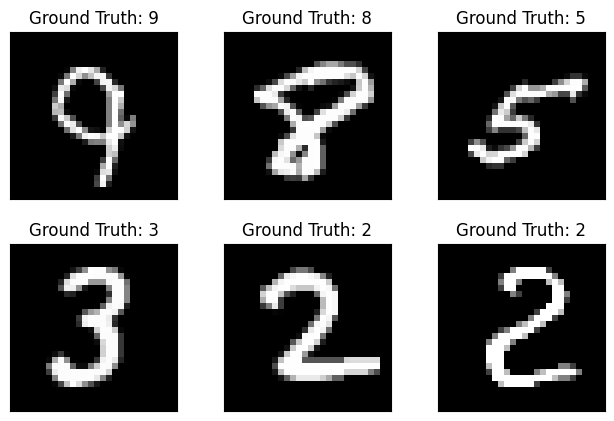

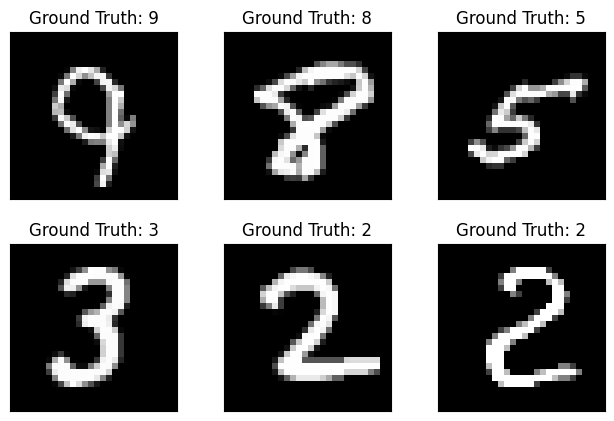

In [29]:
import matplotlib.pyplot as plt

fig = plt.figure()
for i in range(6):
  plt.subplot(2,3,i+1)
  plt.tight_layout()
  plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
  plt.title("Ground Truth: {}".format(example_targets[i]))
  plt.xticks([])
  plt.yticks([])
fig

In [30]:
"""
A fully-connected ReLU network with one hidden layer, trained to predict y from x
by minimizing squared Euclidean distance.

This implementation defines the model as a custom Module subclass. Whenever you
want a model more complex than a simple sequence of existing Modules you will
need to define your model this way.
"""

class TwoLayerNet(torch.nn.Module):
  def __init__(self, D_in, H, D_out):
    """
    In the constructor we instantiate two nn.Linear modules and assign them as
    member variables.
    """
    super(TwoLayerNet, self).__init__()
    self.linear1 = torch.nn.Linear(D_in, H)
    self.linear2 = torch.nn.Linear(H, D_out)

  def forward(self, x):
    """
    In the forward function we accept a Tensor of input data and we must return
    a Tensor of output data. We can use Modules defined in the constructor as
    well as arbitrary (differentiable) operations on Tensors.
    """
    h_relu = self.linear1(x).clamp(min=0)  # ReLU activation
    y_pred = torch.nn.functional.log_softmax(self.linear2(h_relu), dim=1)
    return y_pred

### Time using cpu / gpu

cpu: 5m 12s

gpu (3050Ti Laptop): 5m 11??

In [31]:
# N is batch size; D_in is input dimension;
# H is hidden dimension; D_out is output dimension.
D_in, H, D_out = 784, 100, 10

train_losses = []
train_counter = []
# Construct our model by instantiating the class defined above.
model = TwoLayerNet(D_in, H, D_out)
model = model.to(device)

# Construct our loss function and an Optimizer. The call to model.parameters()
# in the SGD constructor will contain the learnable parameters of the two
# nn.Linear modules which are members of the model.
loss_fn = torch.nn.functional.nll_loss
optimizer = torch.optim.SGD(model.parameters(), lr=loss_rate)
for epoch in range(n_epochs):
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)  # Move data and target to the CUDA device
        x = data.view(-1, 784)
        y_pred = model(x)
        loss = loss_fn(y_pred, target)
        print(f'Epoch {epoch}, Batch {batch_idx}, Loss: {loss.item()}')

        # Zero gradients, perform a backward pass, and update the weights.
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        train_counter.append((batch_idx*64) + ((epoch-1)*len(train_loader.dataset)))


Epoch 0, Batch 0, Loss: 2.327646255493164
Epoch 0, Batch 1, Loss: 2.3303909301757812
Epoch 0, Batch 2, Loss: 2.3156533241271973
Epoch 0, Batch 3, Loss: 2.338848829269409
Epoch 0, Batch 4, Loss: 2.328625440597534
Epoch 0, Batch 5, Loss: 2.314335584640503
Epoch 0, Batch 6, Loss: 2.3162360191345215
Epoch 0, Batch 7, Loss: 2.3188507556915283
Epoch 0, Batch 8, Loss: 2.3049046993255615
Epoch 0, Batch 9, Loss: 2.3071095943450928
Epoch 0, Batch 10, Loss: 2.2989914417266846
Epoch 0, Batch 11, Loss: 2.3040363788604736
Epoch 0, Batch 12, Loss: 2.3208327293395996
Epoch 0, Batch 13, Loss: 2.306788444519043
Epoch 0, Batch 14, Loss: 2.310459852218628
Epoch 0, Batch 15, Loss: 2.3027584552764893
Epoch 0, Batch 16, Loss: 2.2985377311706543
Epoch 0, Batch 17, Loss: 2.3105874061584473
Epoch 0, Batch 18, Loss: 2.3056437969207764
Epoch 0, Batch 19, Loss: 2.2891974449157715
Epoch 0, Batch 20, Loss: 2.2982826232910156
Epoch 0, Batch 21, Loss: 2.289825916290283
Epoch 0, Batch 22, Loss: 2.2859902381896973
Epoch

Text(0, 0.5, 'negative log likelihood loss')

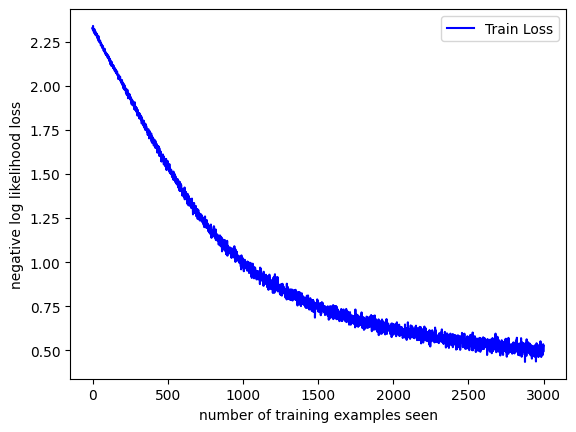

In [32]:
fig = plt.figure()
plt.plot(train_losses, color='blue')
plt.legend(['Train Loss', 'Test Loss'], loc='upper right')
plt.xlabel('number of training examples seen')
plt.ylabel('negative log likelihood loss')


In [33]:
model.eval()
model.cpu()
test_loss = 0
correct = 0
with torch.no_grad():
  for data, target in test_loader:
    data = data.view(-1, 784)
    output = model(data)
    test_loss += torch.nn.functional.nll_loss(output, target, size_average=False).item()
    pred = output.data.max(1, keepdim=True)[1]
    correct += pred.eq(target.data.view_as(pred)).sum()
test_loss /= len(test_loader.dataset)
print('\nTest set: Avg. loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(test_loss, correct, len(test_loader.dataset), 100. * correct / len(test_loader.dataset)))


Test set: Avg. loss: 0.4777, Accuracy: 8867/10000 (89%)

